In [898]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

In [899]:
X, y = load_digits(return_X_y=True)

In [900]:
print(X.shape, y.shape)

(1797, 64) (1797,)


In [901]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

5


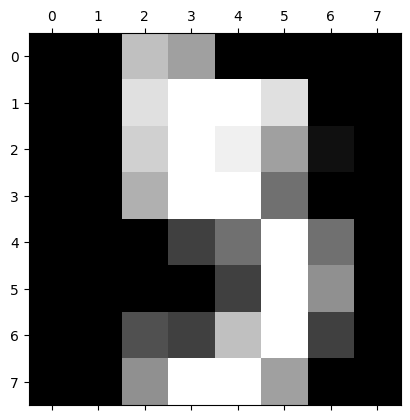

In [902]:
i = 5
plt.matshow(X[i].reshape(8, 8), cmap="gray")
print(y[i])
plt.show()

In [903]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [904]:
from students.pridatchenko.lesson3 import Exercise

In [905]:
numpy_model = Exercise.create_model(
    Exercise.create_linear_layer(64,128),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(128,10),
)

val_model = Exercise.create_model(
    Exercise.create_linear_layer(64,128),
    Exercise.create_relu_layer(),
    Exercise.create_linear_layer(128,10),
)

In [906]:
x = X_train.astype(np.float32)
y = y_train

In [907]:
numpy_loss_fn = Exercise.create_cross_entropy_loss()
val_loss_fn = Exercise.create_cross_entropy_loss()

In [908]:
Exercise.train_model(
    model=numpy_model,
    loss=numpy_loss_fn,
    x=x,
    y=y,
    lr=0.1,
    n_epoch=20,
    batch_size=32
)

In [909]:
n_epochs = 20
history_val_acc = []

for epoch in range(n_epochs):
    Exercise.train_model(
        val_model, val_loss_fn, X_train, y_train, 
        lr=0.1, n_epoch=1, batch_size=32
    )
    
    val_logits = val_model.forward(X_val)
    val_preds = np.argmax(val_logits, axis=1)
    current_val_acc = np.mean(val_preds == y_val)
    
    history_val_acc.append(current_val_acc)
    print(f"Эпоха {epoch+1}/{n_epochs} | Val Accuracy: {current_val_acc:.4f}")

Эпоха 1/20 | Val Accuracy: 0.2583
Эпоха 2/20 | Val Accuracy: 0.5333
Эпоха 3/20 | Val Accuracy: 0.7250
Эпоха 4/20 | Val Accuracy: 0.5833
Эпоха 5/20 | Val Accuracy: 0.8000
Эпоха 6/20 | Val Accuracy: 0.8694
Эпоха 7/20 | Val Accuracy: 0.9278
Эпоха 8/20 | Val Accuracy: 0.9333
Эпоха 9/20 | Val Accuracy: 0.8972
Эпоха 10/20 | Val Accuracy: 0.9306
Эпоха 11/20 | Val Accuracy: 0.9500
Эпоха 12/20 | Val Accuracy: 0.9556
Эпоха 13/20 | Val Accuracy: 0.9583
Эпоха 14/20 | Val Accuracy: 0.9556
Эпоха 15/20 | Val Accuracy: 0.9528
Эпоха 16/20 | Val Accuracy: 0.9528
Эпоха 17/20 | Val Accuracy: 0.9556
Эпоха 18/20 | Val Accuracy: 0.9611
Эпоха 19/20 | Val Accuracy: 0.9611
Эпоха 20/20 | Val Accuracy: 0.9583


Точность на обучении: 100.00%
Точность на валидации: 97.50%
Точность на тесте: 96.67%


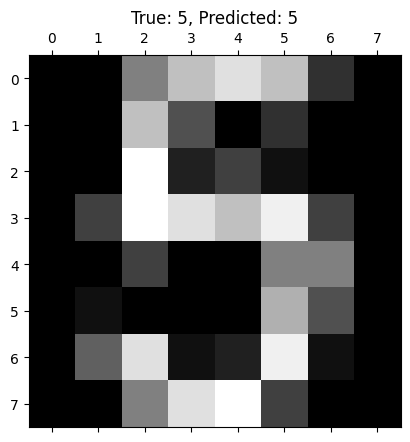

In [910]:
def calculate_accuracy(model, x_data, y_true):
    logits = model.forward(x_data)
    predictions = np.argmax(logits, axis=1)
    return np.mean(predictions == y_true)

train_acc = calculate_accuracy(numpy_model, X_train, y_train)
val_acc = calculate_accuracy(numpy_model, X_val, y_val)
test_acc = calculate_accuracy(numpy_model, X_test, y_test)

print(f"Точность на обучении: {train_acc * 100:.2f}%")
print(f"Точность на валидации: {val_acc * 100:.2f}%")
print(f"Точность на тесте: {test_acc * 100:.2f}%")

sample_idx = 0
sample_x = X_test[sample_idx:sample_idx+1]
sample_y = y_test[sample_idx]

pred = np.argmax(numpy_model.forward(sample_x))
plt.matshow(X_test[sample_idx].reshape(8, 8), cmap="gray")
plt.title(f"True: {sample_y}, Predicted: {pred}")
plt.show()